# 03 · Pipeline de inferencia, resolución y reglas de negocio

Tres bloques:
1. **Resolución:** cómo se adaptan imágenes con otros píxeles (letterbox / resize) y cómo vuelven las cajas a coordenadas originales. *No requiere modelo.*
2. **Reglas de negocio** (decisión, ROI, persistencia, duplicados, severidad) explicadas con casos sintéticos. *No requiere modelo.*
3. **Inferencia real** sobre una carpeta y revisión de sus salidas. *Requiere `models/best_model.pt` y `ultralytics`.*

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd() if (Path.cwd() / "helpers.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(_nb))
from helpers import *   # utilidades compartidas (pd, plt, np, run, read_json, show_images...)

REPO = setup()          # cambia el directorio de trabajo a la raíz del repo
print("Repositorio:", REPO)

Repositorio: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision


In [2]:
DATASET_ROOT = env("DATASET_ROOT", "src/data/kaggle_dataset")
RUN_DIR      = env("RUN_DIR", "outputs/latest")
SOURCE       = env("SOURCE", f"{DATASET_ROOT}/test/images")   # carpeta de imágenes a procesar
RESIZE_MODE  = "letterbox"      # letterbox | resize | none
MODE         = "independent"    # independent | sequence
CONF         = 0.25
RUN_INFERENCE = False           # True: ejecuta src/inference.py desde aquí

## 1. Adaptación de resolución (letterbox / resize)

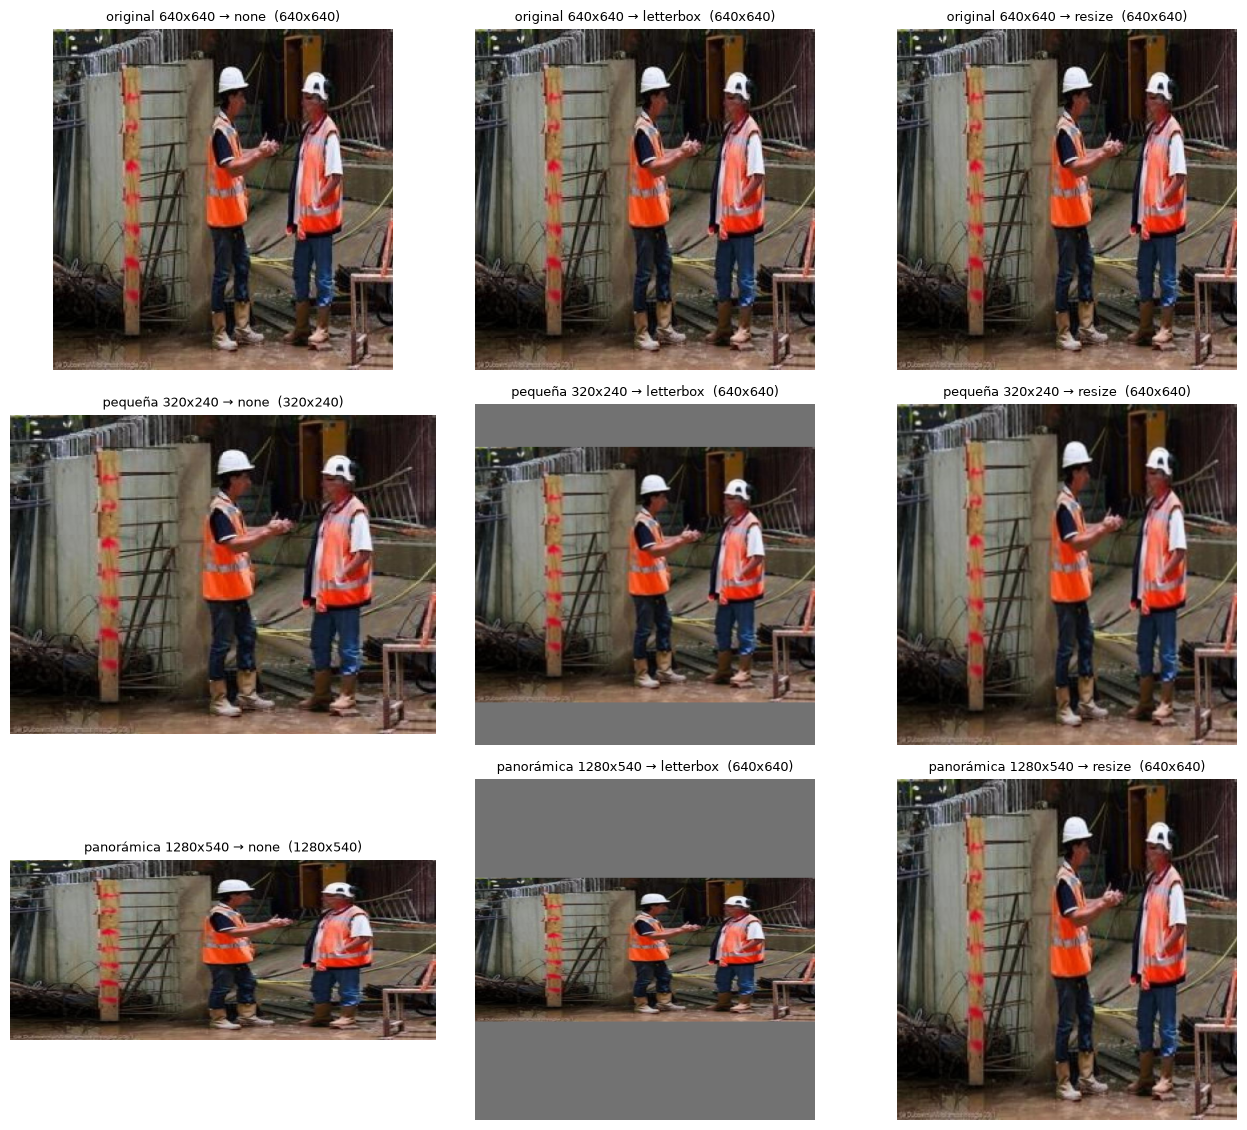

In [3]:
import cv2
from ppe.data.dataset import list_images
from ppe.inference.preprocess import preprocess

imgs = list_images(Path(SOURCE)) if Path(SOURCE).exists() else []
if not imgs:
    print("No hay imágenes en SOURCE:", SOURCE)
else:
    base = read_bgr(imgs[0])
    h0, w0 = base.shape[:2]
    # simulamos cámaras con otra resolución reescalando la misma imagen
    variants = {f"original {w0}x{h0}": base,
                "pequeña 320x240": cv2.resize(base, (320, 240)),
                "panorámica 1280x540": cv2.resize(base, (1280, 540))}
    fig, ax = plt.subplots(len(variants), 3, figsize=(13, 3.8 * len(variants)))
    for r, (name, img) in enumerate(variants.items()):
        for c, mode in enumerate(("none", "letterbox", "resize")):
            out, info = preprocess(img, 640, mode)
            ax[r, c].imshow(bgr2rgb(out)); ax[r, c].axis("off")
            ax[r, c].set_title(f"{name} → {mode}  ({out.shape[1]}x{out.shape[0]})", fontsize=9)
    plt.tight_layout(); plt.show()

Con `letterbox` la proporción se conserva y se añaden bordes grises; con `resize` la imagen se estira (las personas se deforman).
Comprobación de que una caja **vuelve exactamente a coordenadas originales**:

In [4]:
img = np.zeros((720, 1280, 3), dtype=np.uint8)
orig_box = (400.0, 200.0, 600.0, 500.0)
for mode in ("letterbox", "resize"):
    _, info = preprocess(img, 640, mode)
    in_model = (orig_box[0] * info.scale_x + info.pad_x, orig_box[1] * info.scale_y + info.pad_y,
                orig_box[2] * info.scale_x + info.pad_x, orig_box[3] * info.scale_y + info.pad_y)
    back = info.to_original(in_model)
    print(f"{mode:9s} caja en el espacio del modelo: {tuple(round(v, 1) for v in in_model)} -> de vuelta: {back}")
    assert np.allclose(back, orig_box)

letterbox caja en el espacio del modelo: (200.0, 240.0, 300.0, 390.0) -> de vuelta: (400.0, 200.0, 600.0, 500.0)
resize    caja en el espacio del modelo: (200.0, 177.8, 300.0, 444.4) -> de vuelta: (400.0, 200.0, 600.0, 500.0)


## 2. Reglas de negocio

### 2.1 Estrategias de decisión
Para cada persona, la confianza máxima de cada EPP asociado decide si "falta" casco/chaleco.

In [5]:
from ppe.rules.association import PersonPPE
from ppe.rules.events import STRATEGIES, condition_key, missing_ppe, resolve_event
from ppe.config import load_yaml

rules = load_yaml("configs/rules.yaml")
cases = {
    "casco y chaleco detectados":      PersonPPE(helmet=0.9, vest=0.8),
    "nada asociado (ni positivo ni negativo)": PersonPPE(),
    "no_helmet explícito, chaleco ok": PersonPPE(no_helmet=0.8, vest=0.9),
    "no_helmet y no_vest explícitos":  PersonPPE(no_helmet=0.7, no_vest=0.8),
    "casco 0.5 vs no_helmet 0.8":      PersonPPE(helmet=0.5, no_helmet=0.8, vest=0.9),
    "casco 0.8 vs no_helmet 0.5":      PersonPPE(helmet=0.8, no_helmet=0.5, vest=0.9),
}
rows = []
for name, ppe in cases.items():
    row = {"caso": name}
    for strat in STRATEGIES:
        key = condition_key(*missing_ppe(ppe, strat))
        row[strat] = "—" if key is None else "{} [{}]".format(*resolve_event(key, rules["events"]))
    rows.append(row)
display(pd.DataFrame(rows).set_index("caso"))

,association,explicit,hybrid
caso,,,
casco y chaleco detectados,—,—,—
nada asociado (ni positivo ni negativo),persona_sin_casco_y_chaleco [critica],—,persona_sin_casco_y_chaleco [critica]
"no_helmet explícito, chaleco ok",persona_sin_casco [alta],persona_sin_casco [alta],persona_sin_casco [alta]
no_helmet y no_vest explícitos,persona_sin_casco_y_chaleco [critica],persona_sin_casco_y_chaleco [critica],persona_sin_casco_y_chaleco [critica]
casco 0.5 vs no_helmet 0.8,—,persona_sin_casco [alta],persona_sin_casco [alta]
casco 0.8 vs no_helmet 0.5,—,—,—


### 2.2 ROI: la persona está dentro si sus **pies** (centro inferior de la caja) caen en el polígono

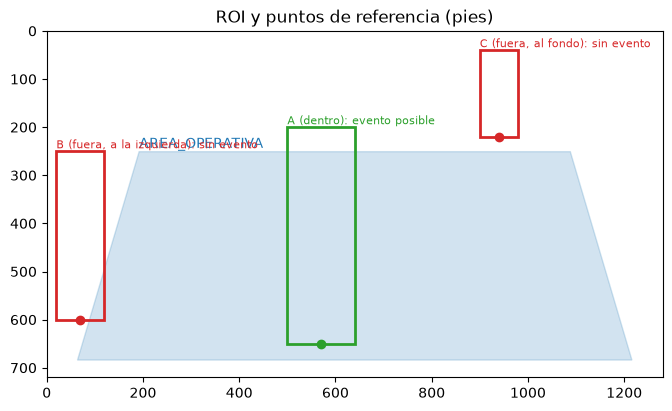

In [6]:
from ppe.rules.roi import ROI, Zone

W, H = 1280, 720
roi = ROI([Zone("AREA_OPERATIVA", [(0.15, 0.35), (0.85, 0.35), (0.95, 0.95), (0.05, 0.95)])])
people = {"A (dentro)": (500, 200, 640, 650), "B (fuera, a la izquierda)": (20, 250, 120, 600),
          "C (fuera, al fondo)": (900, 40, 980, 220)}
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.set_aspect("equal")
for zid, pts in roi.polygons_px((W, H)):
    ax.fill(*zip(*pts), alpha=0.2, color="tab:blue"); ax.text(pts[0][0], pts[0][1] - 8, zid, color="tab:blue")
for name, b in people.items():
    zone = roi.locate(b, (W, H))
    color = "tab:green" if zone else "tab:red"
    ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec=color, lw=2))
    ax.plot((b[0] + b[2]) / 2, b[3], "o", color=color)
    ax.text(b[0], b[1] - 6, f"{name}: {'evento posible' if zone else 'sin evento'}", color=color, fontsize=8)
plt.title("ROI y puntos de referencia (pies)"); plt.show()

### 2.3 Persistencia temporal, duplicados y severidad
Simulamos una persona **sin casco** que parpadea (la detección falla en un frame), luego **cambia de `track_id`** y finalmente también **se quita el chaleco**.

In [7]:
from ppe.rules.events import EventManager, PersonObs

BOX = (100.0, 100.0, 200.0, 400.0)
def obs(cond="sin_casco", key=1, box=BOX):
    return PersonObs(key, key, box, 0.9, f"pred-{key}", cond, True, "AREA_OPERATIVA")

mgr = EventManager(rules["persistence"]["sequence"], rules["events"], "1.0.0", "demo")
fps = 5.0
B2 = (102, 101, 201, 401)          # misma persona, caja casi idéntica pero con otro track_id
timeline = {}
for f in (0, 1, 3, 4, 5, 6):                 # frames 0-6 con un parpadeo en el 2 (hueco tolerado)
    timeline[f] = obs()
for f in range(7, 13):                       # el tracker pierde el id: la misma persona pasa a track 2
    timeline[f] = obs(key=2, box=B2)
for f in range(13, 20):                      # además se quita el chaleco: la condición escala a crítico
    timeline[f] = obs(cond="sin_casco_y_chaleco", key=2, box=B2)
log = []
for f in range(20):
    o = timeline.get(f)
    for e in mgr.update("video_demo", "CAM_01", f, f / fps, [o] if o else []):
        log.append({"frame": f, "evento": e["event_type"], "severidad": e["severity"], "track": e["track_id"],
                    "inicio_frame": e["start_frame_id"], "latencia_s": e["latency_seconds"]})
display(pd.DataFrame(log))
print("Estadísticas de duplicados suprimidos:", dict(mgr.stats))

,frame,evento,severidad,track,inicio_frame,latencia_s
0,5,persona_sin_casco,alta,1,0,1.0
1,18,persona_sin_casco_y_chaleco,critica,2,13,1.0


Estadísticas de duplicados suprimidos: {'emitted': 2, 'suppressed_track_switch': 1}


Lectura: el evento «sin casco» aparece **una sola vez** (tras ≥ 5 frames y ≥ 1 s, con el parpadeo tolerado); el cambio de
`track_id` **no genera un duplicado** (se cuenta en `suppressed_track_switch`), y la escalada a «sin casco y sin chaleco»
produce un evento nuevo de severidad **crítica**.

## 3. Inferencia real

In [8]:
if RUN_INFERENCE:
    run([sys.executable, "src/inference.py", "--source", SOURCE, "--mode", MODE, "--resize-mode", RESIZE_MODE,
         "--conf", CONF, "--save-annotated"], tail=12)
run_dir = Path(RUN_DIR)
ready = exists_or_hint(run_dir / "predictions.jsonl", "Ejecuta src/inference.py (RUN_INFERENCE = True).")

In [9]:
if ready:
    m = read_json(run_dir / "metrics.json")
    print("Volumen:", m["volume"])
    print("Rendimiento:", {k: v for k, v in m["performance"].items() if k != "failed_files"})
    preds = read_jsonl_df(run_dir / "predictions.jsonl")
    events = read_jsonl_df(run_dir / "events.jsonl")
    print(f"\n{len(preds)} detecciones, {len(events)} eventos")
    display(preds[["source_id", "frame_id", "class_name", "confidence", "bbox.x1", "bbox.y1", "bbox.x2", "bbox.y2",
                   "inside_roi", "violation_condition", "event_generated", "event_type", "severity"]].head(10))
    if len(events):
        display(events[["source_id", "event_type", "severity", "track_id", "frame_id", "latency_seconds", "confidence"]].head(10))

Volumen: {'files_found': 406, 'files_processed': 406, 'files_failed': 0, 'videos': 0, 'frames': 406, 'detections': 2811, 'events': 655}
Rendimiento: {'total_seconds': 33.784, 'mean_ms_per_frame': 83.03, 'mean_inference_ms': 78.18, 'p95_inference_ms': 14.57, 'mean_read_preprocess_ms': 4.3, 'fps_end_to_end': 12.02, 'fps_inference_only': 12.79, 'interrupted': False}

2811 detecciones, 655 eventos


,source_id,frame_id,class_name,confidence,bbox.x1,bbox.y1,bbox.x2,bbox.y2,inside_roi,violation_condition,event_generated,event_type,severity
0,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,persona,0.7531,89.7,341.9,112.8,411.4,True,sin_casco,True,persona_sin_casco,alta
1,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,chaleco,0.4637,92.6,353.9,110.8,378.2,True,NaN,False,NaN,NaN
2,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,persona,0.4297,119.9,340.5,138.7,402.2,True,sin_casco_y_chaleco,True,persona_sin_casco_y_chaleco,critica
3,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,sin_chaleco,0.3678,93.1,353.0,110.7,378.3,True,NaN,False,NaN,NaN
4,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,sin_chaleco,0.3107,121.8,351.8,135.6,368.9,True,NaN,False,NaN,NaN
5,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,0,sin_casco,0.2993,99.6,345.7,107.3,353.5,True,NaN,False,NaN,NaN
6,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,0,persona,0.8733,345.3,118.1,482.2,451.0,True,sin_chaleco,True,persona_sin_chaleco,media
7,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,0,persona,0.8672,112.2,17.3,247.0,552.8,True,sin_casco_y_chaleco,True,persona_sin_casco_y_chaleco,critica
8,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,0,persona,0.8659,236.0,375.0,336.6,582.0,True,sin_chaleco,True,persona_sin_chaleco,media
9,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,0,persona,0.8453,482.4,0.0,621.8,622.1,True,sin_chaleco,True,persona_sin_chaleco,media


,source_id,event_type,severity,track_id,frame_id,latency_seconds,confidence
0,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,persona_sin_casco,alta,None,0,0.0,0.7531
1,0_jpg.rf.ca1f126fcce57f271d260a158f0c40b4,persona_sin_casco_y_chaleco,critica,None,0,0.0,0.4297
2,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,persona_sin_chaleco,media,None,0,0.0,0.8733
3,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,persona_sin_casco_y_chaleco,critica,None,0,0.0,0.8672
4,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,persona_sin_chaleco,media,None,0,0.0,0.8659
5,000003_jpg.rf.2c3fe5f104654f46f367b041f5e42814,persona_sin_chaleco,media,None,0,0.0,0.8453
6,000005_jpg.rf.fc2bef6376749917a57f4b270c64fa96,persona_sin_chaleco,media,None,0,0.0,0.6539
7,000010_jpg.rf.364564a48732cc7d3689f88cd1281a5b,persona_sin_casco,alta,None,0,0.0,0.7091
8,20_jpg.rf.9faf150d3acf2be5068d1ddd95f96436,persona_sin_casco_y_chaleco,critica,None,0,0.0,0.8713
9,20_jpg.rf.9faf150d3acf2be5068d1ddd95f96436,persona_sin_casco_y_chaleco,critica,None,0,0.0,0.7820


### Evidencia visual (imágenes anotadas con ROI, persona y evento)

In [10]:
if ready:
    ann = sorted((run_dir / "annotated").rglob("*.jpg"))[:6]
    show_images(ann, cols=3, size=(6, 4))

No hay imágenes para mostrar todavía.


### Comprobaciones de calidad de la salida
Las cajas deben estar dentro de la imagen original y cada línea del JSONL debe ser JSON válido.

In [11]:
if ready:
    bad = preds[(preds["bbox.x1"] < 0) | (preds["bbox.y1"] < 0) | (preds["bbox.x2"] > preds["image_width"]) | (preds["bbox.y2"] > preds["image_height"])]
    print("Cajas fuera de la imagen original:", len(bad))
    print("Resoluciones de entrada:", preds.groupby(["image_width", "image_height"]).size().to_dict())
    print("Líneas JSON inválidas:", sum(1 for line in (run_dir / "predictions.jsonl").read_text(encoding="utf-8").splitlines()
                                        if line.strip() and not line.strip().startswith("{")))

Cajas fuera de la imagen original: 0
Resoluciones de entrada: {(640, 640): 2811}
Líneas JSON inválidas: 0
